In [1]:
library(tidyverse)
library(ggraph)
library(igraph)
library(scales)
library(ggplot2)
library(ggpubr)
library(Seurat)
library(ComplexHeatmap)
library(colorRamps)
library(circlize) 
library(dplyr)


-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4          v readr     2.1.5     
v forcats   1.0.0          v stringr   1.5.2     
v ggplot2   4.0.0.9000     v tibble    3.3.0     
v lubridate 1.9.4          v tidyr     1.3.1     
v purrr     1.1.0          
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'igraph'


The following objects are masked from 'package:lubridate':

    %--%, union


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:purrr':

    compose, simplify


The following object is masked from 'package:tidyr':

    crossing


The following object is masked from 'package:tibble':

    as_data_frame


The fol

In [3]:
plot_lr_bipartite <- function(df,
                              left = "TF_module",
                              right = "TF_module1",
                              edge_width = "tf_prop",
                              edge_color = "meanDiffcors",
                              node_size = 3.8,
                              left_title = "NTC",
                              right_title = "KO") {
  
  df$Rewiring_Index[df$Rewiring_Index<0.2]=0
  df$Rewiring_Index[df$Rewiring_Index>0.7]=0.7
  df <- df %>% mutate(across(all_of(c(left, right)), as.character))
  
  edges <- df %>%
    transmute(from = paste0("L:", .data[[left]]),
              to   = paste0("R:", .data[[right]]),
              edge_w = .data[[edge_width]],
              edge_c = .data[[edge_color]] )
  nodes_left  <- df %>% distinct(label = .data[[left]])  %>%
    transmute(name = paste0("L:", label), label, side = "left", ord = row_number())
  nodes_right <- df %>% distinct(label = .data[[right]]) %>%
    transmute(name = paste0("R:", label), label, side = "right", ord = row_number())
  nodes <- bind_rows(nodes_left, nodes_right)
  lay <- nodes %>%
    group_by(side) %>% arrange(ord, .by_group = TRUE) %>%
    mutate(x = if_else(side == "left", 0, 1),
           y = rescale(-row_number(), to = c(1, 0))) %>%
    ungroup() %>% select(name, x, y)
  g <- graph_from_data_frame(edges, vertices = nodes, directed = FALSE)
  rng <- range(E(g)$edge_c, finite = TRUE)
  lay <- lay[match(V(g)$name, lay$name), ]
  
  ggraph(g, layout = "manual", x = lay$x, y = lay$y) +
    geom_edge_link(aes(edge_width = edge_w, edge_colour = edge_c),
                   alpha = 0.8, lineend = "round", edge_curvature = 0.08) +
    scale_edge_width(range = c(0,1.6), name = edge_width,breaks=c(0.3,0.5,0.7)) +
    scale_edge_colour_gradient2(low = "#f1a340",
                                mid = "#f7f7f7", 
                                high = "#6e016b",
                                midpoint = 0.4,
                                limits = c(0.2, 0.7),
                                breaks   = scales::pretty_breaks(n = 4),
                                name = edge_color) +
    geom_node_point(size = node_size, 
                    shape = 20, 
                    stroke = 0.8,
                    fill = "white", 
                    colour = "black",
                    show.legend = FALSE) +
    geom_node_text(aes(label = label,
                       hjust = if_else(side == "left", 1.5, -0.5)),
                   size = 8) +
    coord_cartesian(xlim = c(-0.25, 1.25)) +
    theme_void(base_size = 12) +
    theme(legend.position = "right",
          plot.margin = margin(10, 30, 10, 30)) +
    annotate("text", x = -0.05, y = 1.04, label = paste0("", left_title),
             hjust = 1, size = 4.2) +
    annotate("text", x =  1.05, y = 1.04, label = paste0("", right_title),
             hjust = 0, size = 4.2)
}

Warning message:
"The input is a data frame-like object, convert it to a matrix."


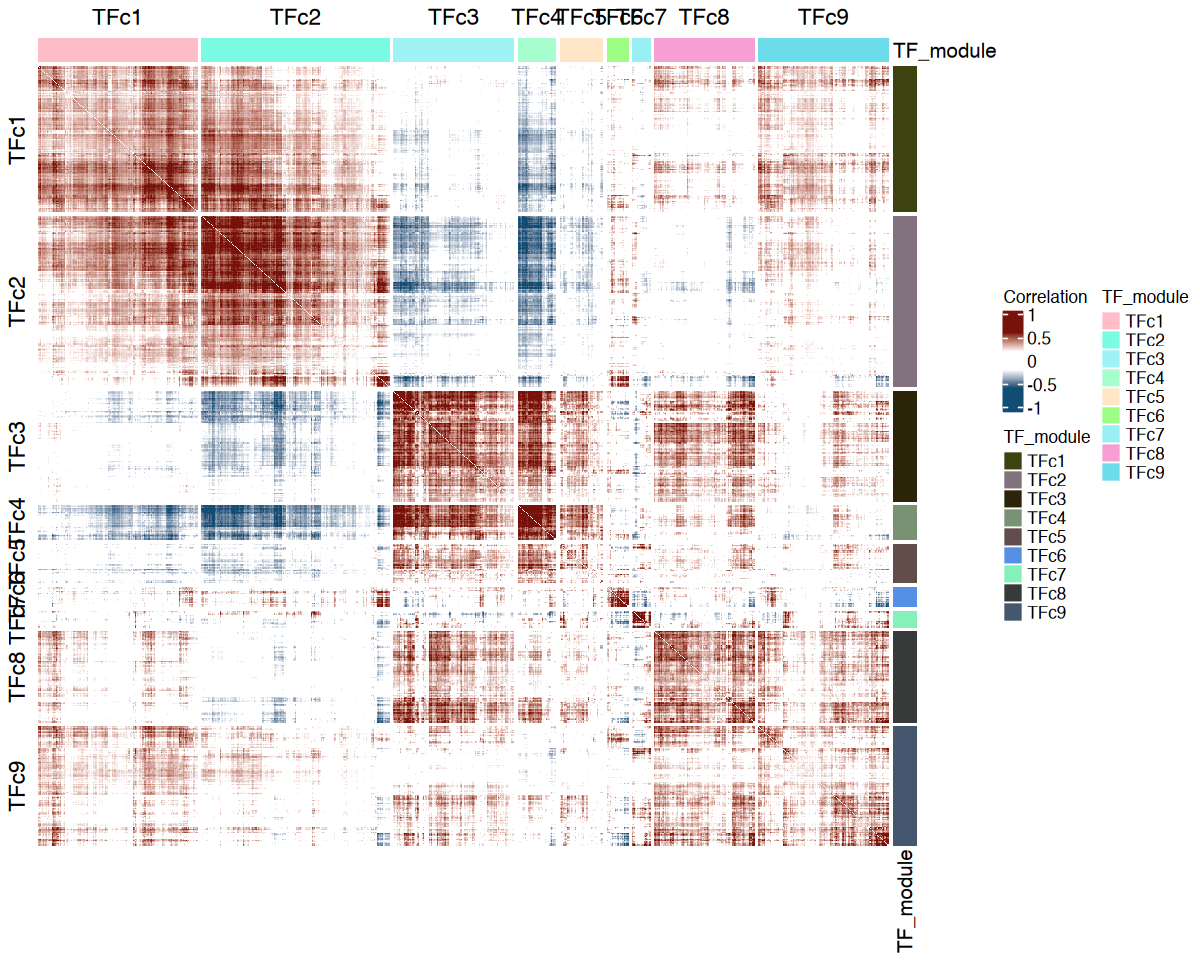

In [4]:
NTC_TF_cluster<-read.csv("TF_clusters_NTC.csv",
                         header = T,
                         row.names = 1,
                         check.names = F)

NTC_TF_correlation<-read.csv("TF_correlation_NTC.csv",
                            header = T,
                            row.names = 1,
                            check.names = F)
NTC_TF_correlation=NTC_TF_correlation[NTC_TF_cluster$RowName,NTC_TF_cluster$RowName]
NTC_TF_cluster$Group=paste0("TFc",NTC_TF_cluster$Group)
rowanno<-rowAnnotation(TF_module=NTC_TF_cluster$Group)
colanno = HeatmapAnnotation( TF_module= NTC_TF_cluster$Group )


color =colorRamp2(c(-0.6,-0.2, 0.2, 0.6), c("#114D72", "white","white", "#78110C"))
NTC_TF_correlation[NTC_TF_correlation>0.6]=0.6
NTC_TF_correlation[NTC_TF_correlation<(-0.6)]=-0.6

p1=ComplexHeatmap::Heatmap(NTC_TF_correlation,
                           show_row_names = F, 
                           show_column_names = F, 
                           show_column_dend = FALSE,
                           cluster_columns = F,
                           cluster_rows = F,
                           col=color,
                           name="Correlation",
                           row_split = NTC_TF_cluster$Group,
                           column_split = NTC_TF_cluster$Group,
                           top_annotation =colanno,
                           right_annotation = rowanno
)
options(repr.plot.width = 10, repr.plot.height =8)
p1

Warning message:
"The input is a data frame-like object, convert it to a matrix."


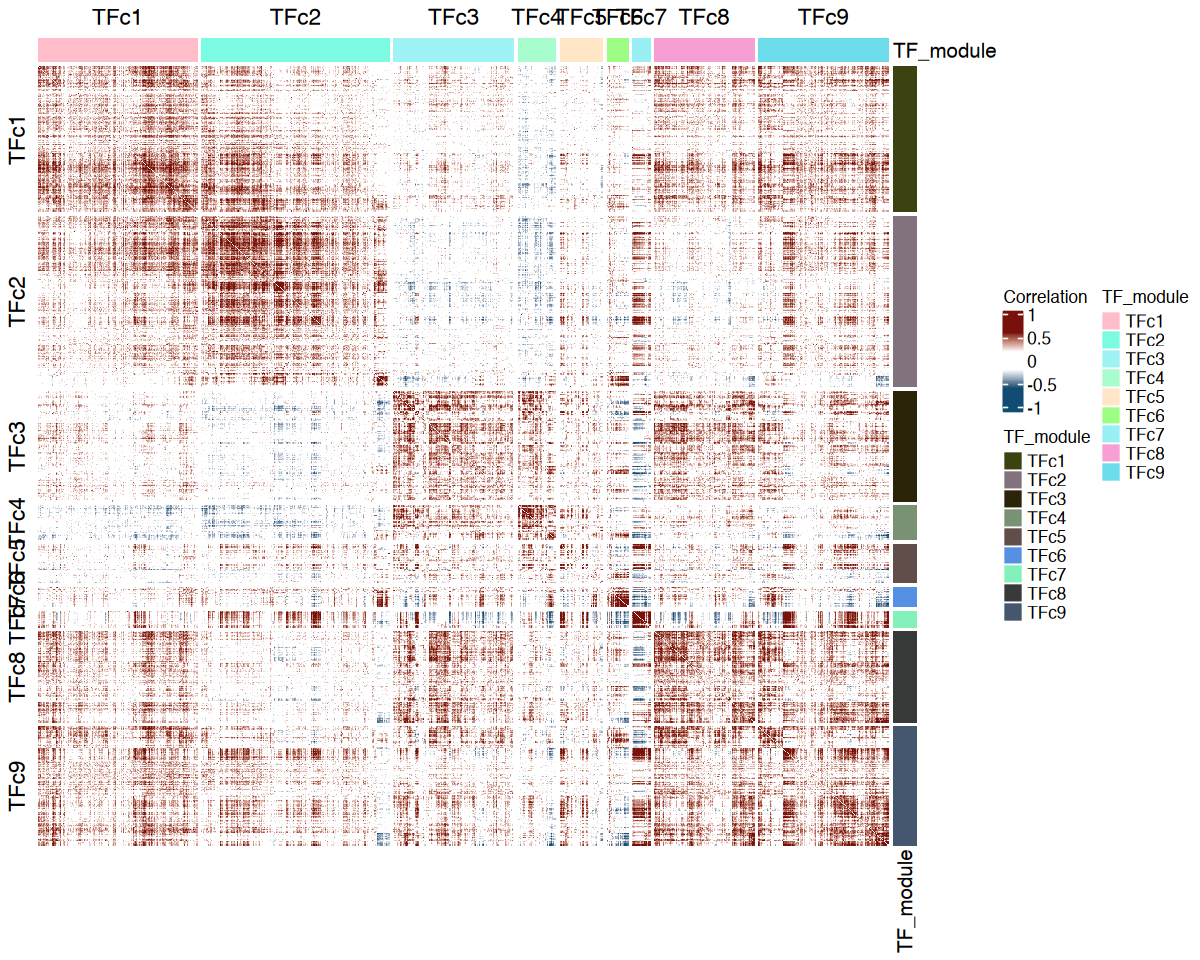

In [5]:
## DDX25 CRISPRi-KO Heatmap
ddx25<-read.csv("DDX25_CRISPR_KO_TF_correlation.csv",
                header = T,row.names = 1,
                check.names = F)
ddx25=ddx25[NTC_TF_cluster$RowName,NTC_TF_cluster$RowName]

color =colorRamp2(c(-0.6,-0.2, 0.2, 0.6), c("#114D72", "white","white", "#78110C"))
ddx25[ddx25>0.6]=0.6
ddx25[ddx25<(-0.6)]=-0.6
p1=ComplexHeatmap::Heatmap(ddx25,
                           show_row_names = F, 
                           show_column_names = F, 
                           show_column_dend = FALSE,
                           cluster_columns = F,
                           cluster_rows = F,
                           col=color,
                           name="Correlation",
                           row_split = NTC_TF_cluster$Group,
                           column_split = NTC_TF_cluster$Group,
                           top_annotation =colanno,
                           right_annotation = rowanno
)

p1


Warning message:
"The input is a data frame-like object, convert it to a matrix."


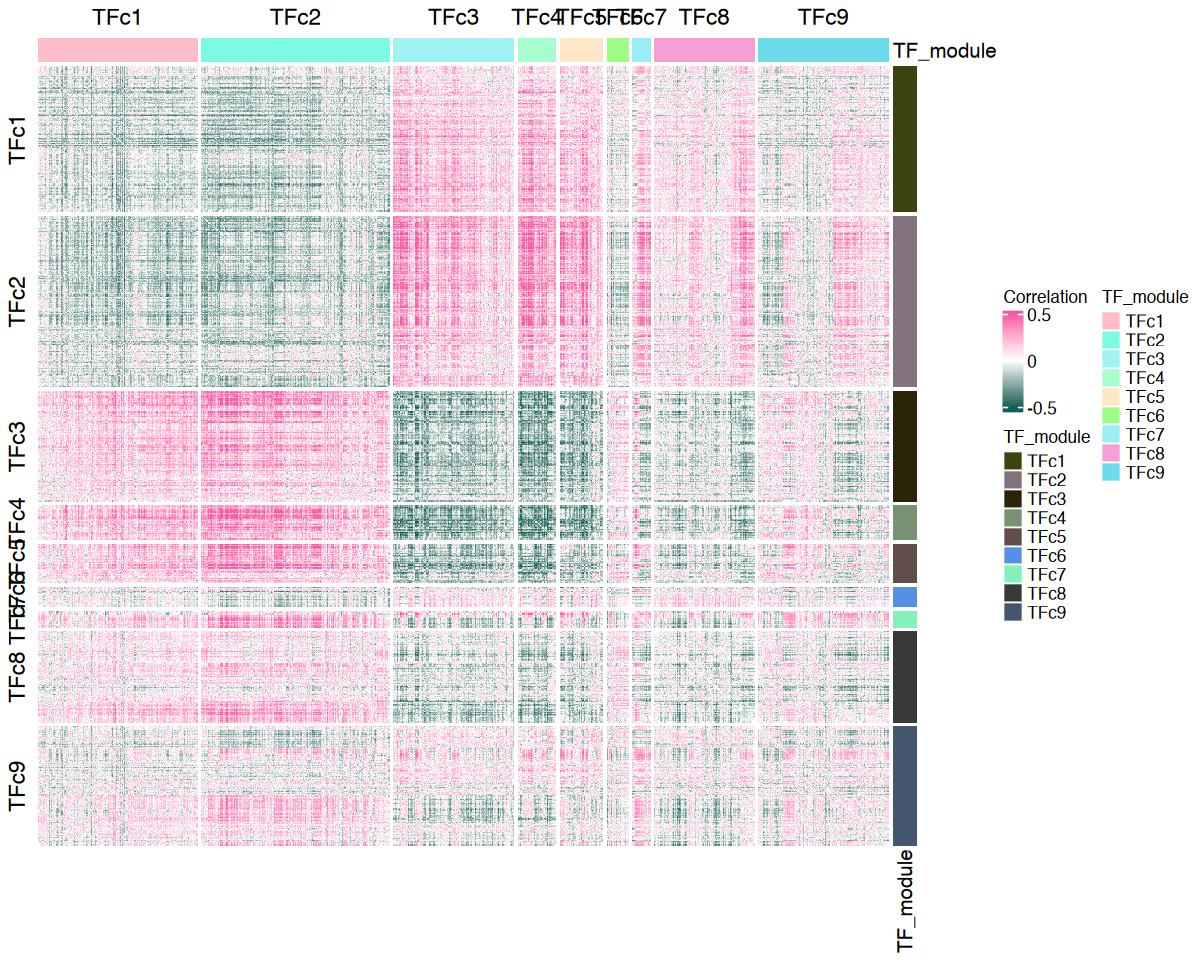

In [6]:
## DDX25 CRISPRi-KO  vs NTC
ddx25_tf_difference<-read.csv("DDX25_CRISPR_KO_TF_correlation_difference_vs_NTC.csv",
                              header = T,
                              row.names = 1
                              ,check.names = F)
ddx25_tf_difference=ddx25_tf_difference[NTC_TF_cluster$RowName,NTC_TF_cluster$RowName]


color =colorRamp2(c(-0.5,0, 0.5), c("#0F6056", "white", "#F25AA6"))
ddx25_tf_difference[ddx25_tf_difference>0.5]=0.5
ddx25_tf_difference[ddx25_tf_difference<(-0.5)]=-0.5
p1=ComplexHeatmap::Heatmap(ddx25_tf_difference,
                           show_row_names = F, 
                           show_column_names = F, 
                           show_column_dend = FALSE,
                           cluster_columns = F,
                           cluster_rows = F,
                           col=color,
                           name="Correlation",
                           row_split = NTC_TF_cluster$Group,
                           column_split = NTC_TF_cluster$Group,
                           top_annotation =colanno,
                           right_annotation = rowanno
)

p1


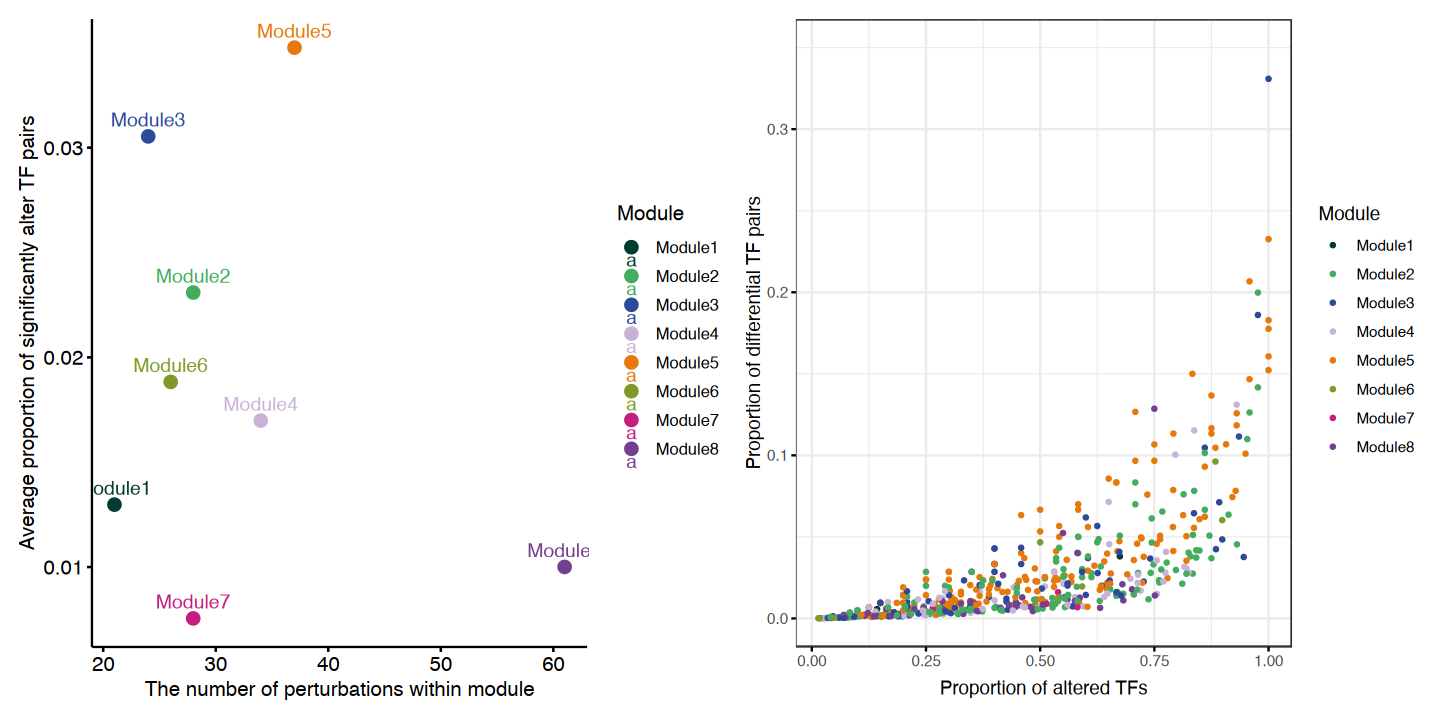

In [7]:
disrupt_tf_pairs<-read.csv("Number of TF_pairs disrupt per module.csv",
                           header = T,
                           row.names = 1,
                           check.names = F)
tf_top<-read.csv("Perturbation_per_module_tf_disrupt.csv",
                 header = T,
                 row.names = 1,
                 check.names = F)
modulecol <- c("#003C30", "#43AC5E", "#2D4999", "#C9B2D6", 
               "#E6780C", "#7E9A29","#C51E7E", "#723F91")


p2=ggscatter(tf_top, x = "prop_alt_tf", 
             y = "prop_above_0.3", 
             color = "Module", 
             palette = modulecol, 
             size=0.8,
             repel = T,
             legend = "right", 
             ggtheme = theme_bw(),
             xlab = "Proportion of altered TFs",
             ylab = "Proportion of differential TF pairs",
             ylim=c(0,0.35))



module_alterd_proportion<-tf_top%>%group_by(Module)%>%summarise(mean_proportion=mean(prop_above_0.3))

module_alterd_proportion<-left_join(module_alterd_proportion,disrupt_tf_pairs[,c("Perturbations","Module")],by="Module")


p1=ggscatter(module_alterd_proportion,
            x="Perturbations",
            y="mean_proportion",
            color = "Module", 
            legend="right",
            size = 3,
            xlab="The number of perturbations within module",
            ylab="Average proportion of significantly alter TF pairs",
            fill="Module",
            label = "Module",
            palette = modulecol,
           # ylim=c(0,0.35),
)

p=p1+p2
options(repr.plot.width = 12, repr.plot.height =6)
p


In [ ]:
selecttf <- c("ASB11","AUTS2","CALB2","DDX25","IL1RL1","MAPK10","NPTN","POSTN","TREM1","TSPYL6")

for (ts in selecttf){
  changetfProplong<-read.csv(paste0(ts,"_tf_change_prop_mean_diff_cors_in_module_plot.csv"),header = T,check.names = F,row.names = 1)
  changetfProplong$labelid=changetfProplong$modules
  changetfProplong$tf_prop=as.numeric(changetfProplong$tf_prop)
  changetfProplong=data.frame(changetfProplong)
  changetfProplong$TF_module=factor(changetfProplong$TF_module,levels = c(1:9))
  changetfProplong$TF_module1=factor(changetfProplong$TF_module1,levels = c(1:9))
  
  library(scales)
  changetfProplong$tf_prop_01 <- rescale(changetfProplong$tf_prop, to = c(0, 1))   # 自动跳过 NA
  changetfProplong$meanDiffcors_01 <- rescale(changetfProplong$meanDiffcors, to = c(0, 1))   # 自动跳过 NA
  changetfProplong$Rewiring_Index=changetfProplong$tf_prop_01*changetfProplong$meanDiffcors_01
  p <- plot_lr_bipartite(changetfProplong,
                         left = "TF_module",
                         right = "TF_module1",
                         edge_width = "Rewiring_Index",
                         edge_color = "Rewiring_Index",
                         node_size = 4)

  
}
